In [1]:
# PACKAGES
## data manipulation
import pandas as pd
import numpy as np

## confidence interval
import math

## data viz
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# PATHS AND METHODS

## My min max scaler
def my_scaler(x_unscaled, x_min=None, x_max=None):
    if x_min == None:
        x_min=x_unscaled.min()
    if x_max == None:
        x_max=x_unscaled.max()
    x_scaled = (x_unscaled - x_min)/(x_max - x_min)
    return x_scaled

## confidence interval 95%
def my_ci_95(stats, r=2):
    
    ci95_hi = []
    ci95_lo = []
    alpha = []

    for i in stats.index:
        m, c, s = stats.loc[i]
        a = 1.96*s/math.sqrt(c)
        ci95_hi.append(m + a)
        ci95_lo.append(m - a)
        alpha.append(a)

    stats['ci95_lo'] = ci95_lo
    stats['ci95_hi'] = ci95_hi
    stats['alpha'] = alpha

    stats['mean'] = round(stats['mean'], r)
    stats['alpha'] = round(stats['alpha'], r)

    return(stats.reset_index())

In [3]:
# DEFINING EXPERIMENT PARAMETERS
## seed list
seed_list = [428956419, 1954324947, 1145661099, 1835732737, 794161987, 1329531353, 200496737, 633816299, 1410143363, 1282538739]

## scenarion list
#scenario_list = ['2ec_low_on', '2ec_low_off', '2ec_high_on', '2ec_high_off']
scenario_list = ['2ec_high_off']

## algorithms list
algo_list = ['tetris', 'thea', 'argos', 'faticanti']
#algo_list = ['tetris', 'thea']

In [4]:
# IMPORT DATASETS

# dataframes
total_seed_server = pd.DataFrame()
total_seed_user = pd.DataFrame()
total_seed_service = pd.DataFrame()
# object to count the quantity of experiments
n_exp = 0

# loop to get results
for algo_name in algo_list:

    for scenario in scenario_list:

        ## count experiment
        n_exp = n_exp + 1

        for seed_value in seed_list:

            # server
            ## getting results by seeds
            each_seed_server = pd.read_csv(f"results/{algo_name}_logsserver_{scenario}_{seed_value}.csv")
            each_seed_server['seed'] = seed_value
            each_seed_server['scenario'] = scenario
            each_seed_server['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_server = pd.concat([total_seed_server, each_seed_server])
            total_seed_server = total_seed_server.reset_index(drop=True)

            # user
            ## getting results by seeds
            each_seed_user = pd.read_csv(f"results/{algo_name}_logsuser_{scenario}_{seed_value}.csv")
            each_seed_user['seed'] = seed_value
            each_seed_user['scenario'] = scenario
            each_seed_user['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_user = pd.concat([total_seed_user, each_seed_user])
            total_seed_user = total_seed_user.reset_index(drop=True)

            # service
            ## getting results by seeds
            each_seed_service = pd.read_csv(f"results/{algo_name}_logsservice_{scenario}_{seed_value}.csv")
            each_seed_service['seed'] = seed_value
            each_seed_service['scenario'] = scenario
            each_seed_service['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_service = pd.concat([total_seed_service, each_seed_service])
            total_seed_service = total_seed_service.reset_index(drop=True)

In [5]:
# FEATURE ENGINEERING

## create new obj to do feature engineering
dt_power = total_seed_server.loc[(total_seed_server['Available'])].reset_index(drop=True).copy()
dt_server = total_seed_server.loc[(total_seed_server['Available']) & (total_seed_server['CPU Demand'] > 0)].reset_index(drop=True).copy()
dt_user = total_seed_user.copy()
dt_service = total_seed_service.copy()

## alogrithm + scenario column
dt_power['algorithm_scenario'] = dt_power['algorithm'] + '_' + dt_server['scenario']
dt_server['algorithm_scenario'] = dt_server['algorithm'] + '_' + dt_server['scenario']
dt_user['algorithm_scenario'] = dt_user['algorithm'] + '_' + dt_user['scenario']
dt_service['algorithm_scenario'] = dt_service['algorithm'] + '_' + dt_service['scenario']

## user dataset
# compute sla violation variable
dt_user['sla_violations'] = 0
dt_user.loc[dt_user['Delay sla deadlines'] < 0, 'sla_violations'] = 1
dt_user['cumulative_sla_violations'] = dt_user.groupby(['algorithm', 'scenario', 'seed'])['sla_violations'].cumsum()

# compute drops
dt_user_drop = dt_user.groupby(by=['algorithm', 'scenario', 'Object','seed'])['Delays'].agg(['last']).reset_index().rename(columns={'last':'Delays'})
dt_user_drop['drop'] = 0
dt_user_drop.loc[dt_user_drop['Delays'].isna(), 'drop'] = 1

## server dataset
# compute server access
dt_server['server_access'] = 0
dt_server.loc[dt_server['CPU Demand'] > 0, 'server_access'] = 1
dt_server['cumulative_server_access'] = dt_server.groupby(['Instance ID', 'algorithm', 'scenario', 'seed'])['server_access'].cumsum()
dt_total_server_access = dt_server.groupby(['algorithm', 'scenario', 'seed'])['server_access'].sum().reset_index().rename(columns={'server_access':'total_server_access'})
dt_server = dt_server.merge(dt_total_server_access, how='left', on=['algorithm', 'scenario', 'seed'])
dt_total_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['total_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_total_server_access_avg['product'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['count']
dt_total_server_access_avg = dt_total_server_access_avg.merge(dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_total_server_access_avg['weight'] = dt_total_server_access_avg['product']/dt_total_server_access_avg['sum']
dt_total_server_access_avg['n_server_access'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['weight']
dt_total_server_access_avg = dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['n_server_access'].agg(['sum']).reset_index().rename(columns={'sum':'n_server_access'})
dt_server_access_avg = dt_server.groupby(by=['algorithm', 'Object', 'scenario', 'seed'])['cumulative_server_access'].agg(['last']).reset_index().groupby(by=['algorithm', 'scenario', 'Object'])['last'].agg(['mean', 'count']).reset_index()
dt_server_access_avg['product'] = dt_server_access_avg['mean']*dt_server_access_avg['count']
dt_server_access_avg = dt_server_access_avg.merge(dt_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['weight'] = dt_server_access_avg['product']/dt_server_access_avg['sum']
dt_server_access_avg = dt_server_access_avg.merge(dt_total_server_access_avg, how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['server_access_by_server'] = dt_server_access_avg['n_server_access']*dt_server_access_avg['weight']


# compute free resources
dt_server['CPU Free'] = dt_server['CPU'] - dt_server['CPU Demand']
dt_server['RAM Free'] = dt_server['RAM'] - dt_server['RAM Demand']
# compute usage metrics
dt_server['CPU Usage'] = (dt_server['CPU Demand'] * 100) / dt_server['CPU']
dt_server['RAM Usage'] = (dt_server['RAM Demand'] * 100) / dt_server['RAM']
dt_server['Servers Usage'] = (dt_server['CPU Usage'] + dt_server['RAM Usage']) / 2

# create new obj withou cloud server
dt_server_edge = dt_server.loc[(dt_server['Instance ID'] != 7)].reset_index(drop=True)

# normalization
## Imbalance
dt_server_edge_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['CPU Free']].apply(my_scaler).reset_index().rename(columns={'CPU Free':'CPU Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_cpu[['CPU Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['RAM Free']].apply(my_scaler).reset_index().rename(columns={'RAM Free':'RAM Free_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_ram[['RAM Free_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
## Fragmentation
dt_server_edge_rf_cpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_cpu']].apply(my_scaler).reset_index().rename(columns={'rf_cpu':'rf_cpu_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_cpu[['rf_cpu_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')
dt_server_edge_rf_ram = dt_server_edge.groupby(by=['algorithm', 'scenario'])[['rf_memory']].apply(my_scaler).reset_index().rename(columns={'rf_memory':'rf_memory_norm'})
dt_server_edge = dt_server_edge.merge(dt_server_edge_rf_ram[['rf_memory_norm', 'level_2']], how='left', left_index=True, right_on='level_2').drop(columns='level_2')

# compute Resource Imbalance Index (RII)
dt_server_edge['RII'] = dt_server_edge[['CPU Free_norm', 'RAM Free_norm']].std(axis=1)
# compute Resource Fragmentation Index (RFI)
dt_server_edge['RFI'] = dt_server_edge[['rf_cpu_norm', 'rf_memory_norm']].mean(axis=1)

In [6]:
# RESULTS TO USE ON OVERLEAF PLOTS

## SLA Violations
stats_sla = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['cumulative_sla_violations'].max().groupby(by=['algorithm', 'scenario']).agg(['mean', 'count', 'std'])
stats_sla = my_ci_95(stats_sla)
print(">>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<\n", stats_sla[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Drop
stats_drop = dt_user_drop.groupby(by=['algorithm', 'scenario', 'seed'])['drop'].sum().groupby(by=['algorithm', 'scenario']).agg(['mean', 'count', 'std'])
stats_drop = my_ci_95(stats_drop)
print(">>>>>>>>>>>>>>>>>>>> drop <<<<<<<<<<<<<<<<<<<<\n", stats_drop[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Delay
stats_delay = dt_user.groupby(by=['algorithm', 'scenario'])['Delays'].agg(['mean', 'count', 'std'])
stats_delay = my_ci_95(stats_delay)
print(">>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<\n", stats_delay[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Power Consumption
stats_power = dt_power.groupby(by=['algorithm', 'scenario'])['Power Consumption'].agg(['mean', 'count', 'std'])
stats_power = my_ci_95(stats_power)
print(">>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<\n", stats_power[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## RFI
stats_rfi = dt_server_edge.groupby(by=['algorithm', 'scenario'])['RFI'].agg(['mean', 'count', 'std'])
stats_rfi = my_ci_95(stats_rfi, r=5)
print(">>>>>>>>>>>>>>>>>>>> RFI <<<<<<<<<<<<<<<<<<<<\n", stats_rfi[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Fragmentation metrics - counter
stats_rfc = dt_server_edge.groupby(by=['algorithm', 'scenario'])['rfc'].agg(['mean', 'count', 'std'])
stats_rfc = my_ci_95(stats_rfc)
print(">>>>>>>>>>>>>>>>>>>> Fragmentation Counter <<<<<<<<<<<<<<<<<<<<\n", stats_rfc[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Fragmentation metrics - cpu
stats_rfcpu = dt_server_edge.groupby(by=['algorithm', 'scenario'])['rf_cpu'].agg(['mean', 'count', 'std'])
stats_rfcpu = my_ci_95(stats_rfcpu)
print(">>>>>>>>>>>>>>>>>>>> CPU Fragmentation <<<<<<<<<<<<<<<<<<<<\n", stats_rfcpu[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Fragmentation metrics - ram
stats_rfram = dt_server_edge.groupby(by=['algorithm', 'scenario'])['rf_memory'].agg(['mean', 'count', 'std'])
stats_rfram = my_ci_95(stats_rfram)
print(">>>>>>>>>>>>>>>>>>>> RAM Fragmentation <<<<<<<<<<<<<<<<<<<<\n", stats_rfram[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## RII
stats_rii = dt_server_edge.groupby(by=['algorithm', 'scenario'])['RII'].agg(['mean', 'count', 'std'])
stats_rii = my_ci_95(stats_rii)
print(">>>>>>>>>>>>>>>>>>>> RII <<<<<<<<<<<<<<<<<<<<\n", stats_rii[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Percent Server Access
stats_access = dt_server_access_avg.groupby(by=['algorithm', 'scenario', 'Object'])['weight'].agg(['mean', 'count', 'std'])
stats_access = my_ci_95(stats_access,  r=2)
stats_access['mean_percent'] = stats_access['mean']*100
print(">>>>>>>>>>>>>>>>>>>> Server Access <<<<<<<<<<<<<<<<<<<<\n", stats_access[['algorithm', 'scenario', 'Object', 'mean_percent']], '\n')

>>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<
    algorithm      scenario   mean  alpha
0      argos  2ec_high_off  229.5  47.22
1  faticanti  2ec_high_off  261.1  17.57
2     tetris  2ec_high_off   19.0   2.86
3       thea  2ec_high_off  225.2  27.50 

>>>>>>>>>>>>>>>>>>>> drop <<<<<<<<<<<<<<<<<<<<
    algorithm      scenario  mean  alpha
0      argos  2ec_high_off   1.0   0.29
1  faticanti  2ec_high_off   1.0   0.00
2     tetris  2ec_high_off   0.0   0.00
3       thea  2ec_high_off   1.6   0.32 

>>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<
    algorithm      scenario   mean  alpha
0      argos  2ec_high_off  28.01   0.30
1  faticanti  2ec_high_off  27.95   0.27
2     tetris  2ec_high_off  30.78   1.27
3       thea  2ec_high_off  29.62   0.27 

>>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<
    algorithm      scenario    mean  alpha
0      argos  2ec_high_off  213.75   1.23
1  faticanti  2ec_high_off  207.91   1.09
2     tetris  2ec_high_off  206.12   4.51


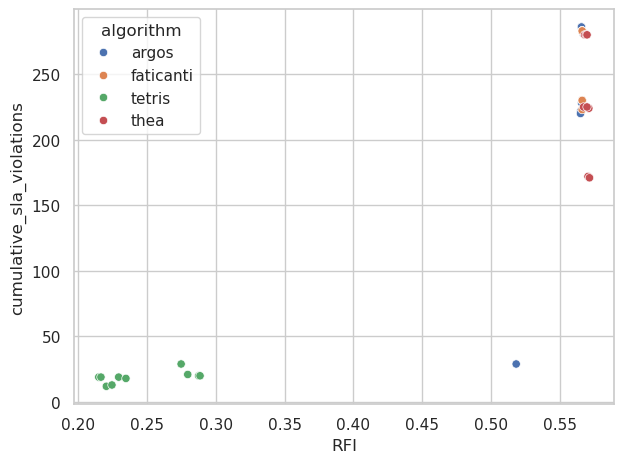

In [7]:
# DATA VIZ

## RFI x SLA
dt_server_rfi = dt_server_edge.groupby(by=['algorithm', 'scenario', 'seed'])['RFI'].mean().reset_index()
dt_user_sla = dt_user.groupby(by=['algorithm', 'scenario', 'seed'])['cumulative_sla_violations'].max().reset_index()
dt_rfi_sla = dt_server_rfi.merge(dt_user_sla, how='left', on=['algorithm', 'scenario', 'seed'])

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.scatterplot(data=dt_rfi_sla, x='RFI', y='cumulative_sla_violations', hue='algorithm')
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()